In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## Dataset (PNAS Smart-seq-total paper)

Large dataset with rows representing genes and column cells, with entries the recorded transcript counts

- ~50,000 genes listed but many have zero counts recorded and are not relevant / useful
- cells belong to 4 groups by day: d0, d4, d8, d12

Cell names
- majority `mESC_EB_d{day}_{letter}{letter_idx}_S{day_idx}`
    - day is 0, 4, 8, 12
    - letters A - P
    - letter index 1 - 17-30 resets to 1 for each new letter
    - day index 1 - 329-411 resets to 1 for each new day
- however also contains:
    - `mESC_d0_p2_{letter}{letter_idx}_S{overall_idx}`
    - `mESC_d0_p3_{letter}{letter_idx}`
- unclear the naming convention, or why the totals per day do not match the 384-well plate used in sequencing

In [3]:
data = pd.read_csv("./GSE151334_counts.mouse.tsv", sep='\t', index_col=0)
data.head()

,mESC_EB_d0_A11_S11,mESC_EB_d0_A12_S12,mESC_EB_d0_A13_S13,mESC_EB_d0_A14_S14,mESC_EB_d0_A15_S15,mESC_EB_d0_A16_S16,mESC_EB_d0_A17_S17,mESC_EB_d0_A18_S18,mESC_EB_d0_A19_S19,mESC_EB_d0_A1_S1,...,mESC_d0_p3_P23,mESC_d0_p3_P24,mESC_d0_p3_P2,mESC_d0_p3_P3,mESC_d0_p3_P4,mESC_d0_p3_P5,mESC_d0_p3_P6,mESC_d0_p3_P7,mESC_d0_p3_P8,mESC_d0_p3_P9
0610005C13Rik,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
0610006L08Rik,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
0610009B22Rik,0,0,0,24,0,0,0,0,0,0,...,0,0,5,1,0,1,0,0,0,3
0610009E02Rik,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,7,0,0,0,0
0610009L18Rik,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0


In [4]:
data.shape

(55293, 2183)

In [5]:
print("Counts per letter per day")
letters = [x for x in "ABCDEFGHIJKLMNOP"]
totals = [0, 0, 0, 0]
for letter in letters:
    counts = []
    for d, day in enumerate([0, 4, 8, 12]):
        count = 0
        for col in data.columns:
            if f"mESC_EB_d{day}_{letter}" in col:
                count += 1
        counts.append(count)
        totals[d] += count
    print(f"{letter} {counts}")
print(f"Counts per day \n{totals}")

Counts per letter per day
A [23, 21, 25, 25]
B [22, 17, 30, 25]
C [18, 19, 26, 27]
D [21, 23, 25, 24]
E [21, 22, 25, 25]
F [23, 21, 26, 25]
G [21, 21, 27, 24]
H [20, 22, 25, 25]
I [20, 23, 25, 24]
J [21, 21, 27, 24]
K [24, 21, 26, 25]
L [21, 21, 25, 25]
M [19, 22, 25, 25]
N [18, 24, 24, 24]
O [22, 22, 25, 25]
P [15, 22, 25, 24]
Counts per day 
[329, 342, 411, 396]


# Separate cells by day

Choose to ignore the additional `p2` and `p3` cells for day 0

In [6]:
d0_columns = [name for name in data.columns if 'mESC_EB_d0' in name]
d4_columns = [name for name in data.columns if 'mESC_EB_d4' in name]
d8_columns = [name for name in data.columns if 'mESC_EB_d8' in name]
d12_columns = [name for name in data.columns if 'mESC_EB_d12' in name]

data_d0 = data[d0_columns]
data_d4 = data[d4_columns]
data_d8 = data[d8_columns]
data_d12 = data[d12_columns]

## Outlying cells

### Total counts

Remove cells with 0 total counts

In [ ]:
# total cell counts
d0_cell_totals = data_d0.sum(axis=0)
d4_cell_totals = data_d4.sum(axis=0)
d8_cell_totals = data_d8.sum(axis=0)
d12_cell_totals = data_d12.sum(axis=0)

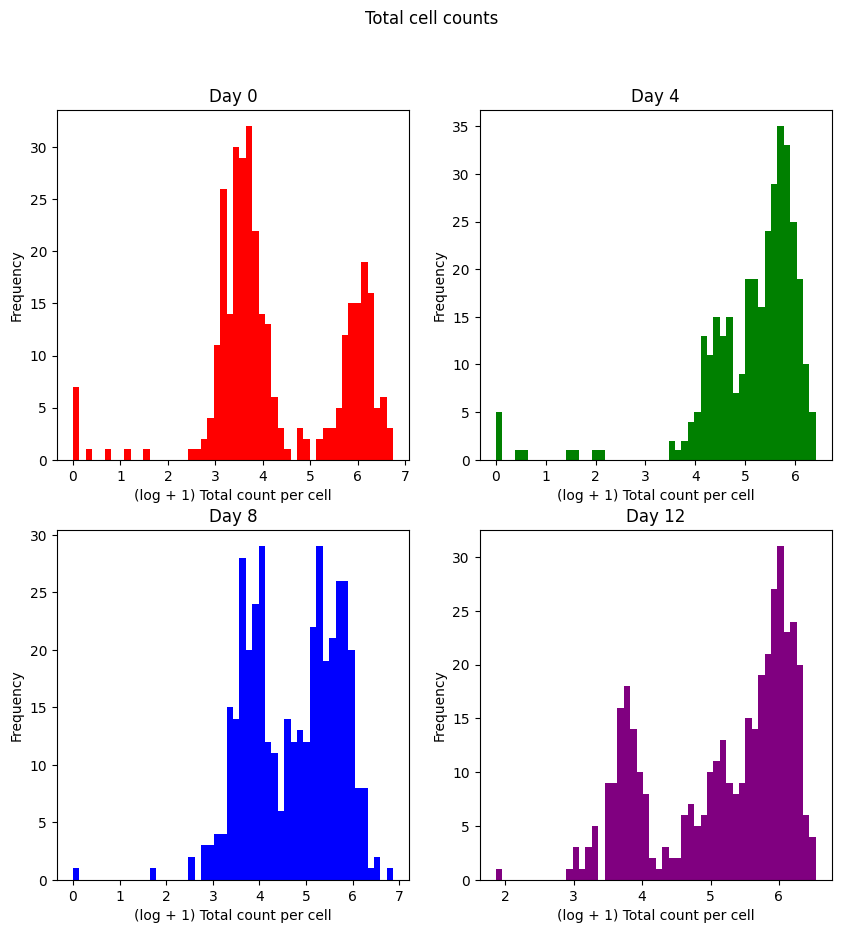

In [11]:
fig, axs = plt.subplots(2, 2, figsize=(10, 10))
plt.suptitle("Total cell counts")
d0_hist = axs[0, 0].hist(np.log10(d0_cell_totals + 1), bins=50, color="red");
axs[0, 0].set_title("Day 0")
axs[0, 0].set_xlabel("(log + 1) Total count per cell")
axs[0, 0].set_ylabel("Frequency")
d4_hist = axs[0, 1].hist(np.log10(d4_cell_totals + 1), bins=50, color="green");
axs[0, 1].set_title("Day 4")
axs[0, 1].set_xlabel("(log + 1) Total count per cell")
axs[0, 1].set_ylabel("Frequency")
d8_hist = axs[1, 0].hist(np.log10(d8_cell_totals + 1), bins=50, color="blue");
axs[1, 0].set_title("Day 8")
axs[1, 0].set_xlabel("(log + 1) Total count per cell")
axs[1, 0].set_ylabel("Frequency")
d12_hist = axs[1, 1].hist(np.log10(d12_cell_totals + 1), bins=50, color="purple");
axs[1, 1].set_title("Day 12")
axs[1, 1].set_xlabel("(log + 1) Total count per cell")
axs[1, 1].set_ylabel("Frequency")
plt.show()

In [15]:
# cells with 0 total counts
sum(d0_cell_totals == 0), sum(d4_cell_totals == 0), sum(d8_cell_totals == 0), sum(d12_cell_totals == 0)

(7, 5, 1, 0)

In [36]:
# select zero count cells
zero_cells_d0 = data_d0.columns[d0_cell_totals == 0]
zero_cells_d4 = data_d4.columns[d4_cell_totals == 0]
zero_cells_d8 = data_d8.columns[d8_cell_totals == 0]
zero_cells_d12 = data_d12.columns[d12_cell_totals == 0]

# drop
data_d0 = data_d0.drop(columns=[*zero_cells_d0])
data_d4 = data_d4.drop(columns=[*zero_cells_d4])
data_d8 = data_d8.drop(columns=[*zero_cells_d8])
data_d12 = data_d12.drop(columns=[*zero_cells_d12])

### Mean counts

Investigate remaining outliers

In [37]:
# mean cell counts
d0_cell_means = data_d0.mean(axis=0)
d4_cell_means = data_d4.mean(axis=0)
d8_cell_means = data_d8.mean(axis=0)
d12_cell_means = data_d12.mean(axis=0)

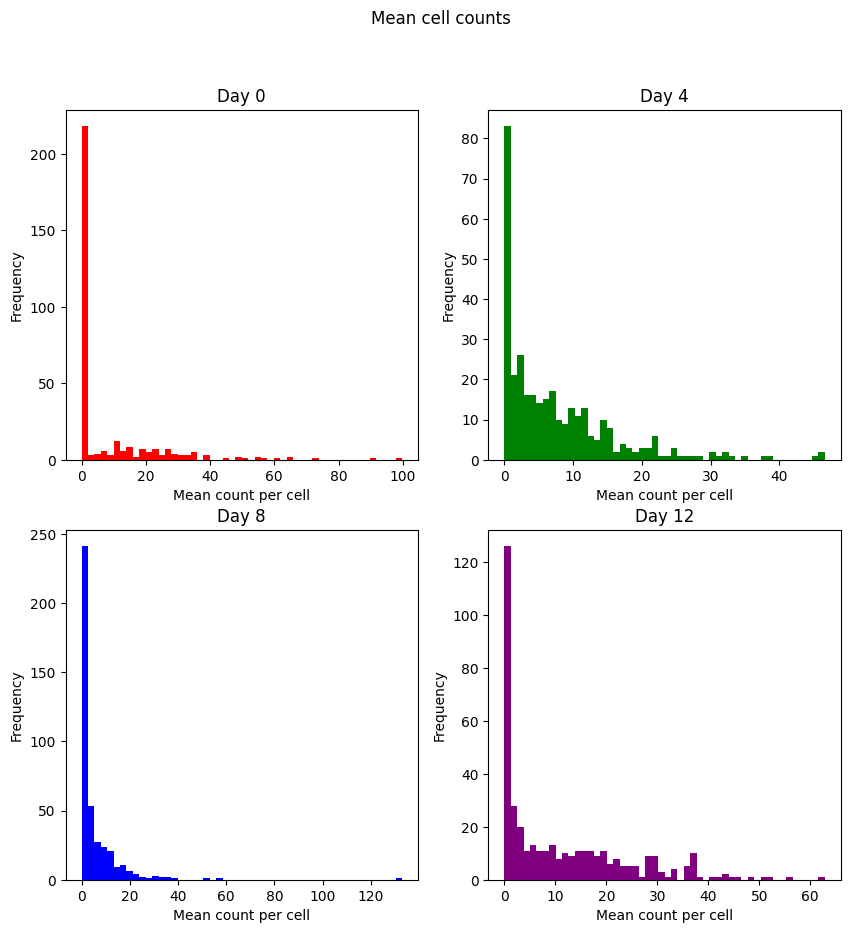

In [39]:
fig, axs = plt.subplots(2, 2, figsize=(10, 10))
plt.suptitle("Mean cell counts")
d0_hist = axs[0, 0].hist(d0_cell_means, bins=50, color="red");
axs[0, 0].set_title("Day 0")
axs[0, 0].set_xlabel("Mean count per cell")
axs[0, 0].set_ylabel("Frequency")
d4_hist = axs[0, 1].hist(d4_cell_means, bins=50, color="green");
axs[0, 1].set_title("Day 4")
axs[0, 1].set_xlabel("Mean count per cell")
axs[0, 1].set_ylabel("Frequency")
d8_hist = axs[1, 0].hist(d8_cell_means, bins=50, color="blue");
axs[1, 0].set_title("Day 8")
axs[1, 0].set_xlabel("Mean count per cell")
axs[1, 0].set_ylabel("Frequency")
d12_hist = axs[1, 1].hist(d12_cell_means, bins=50, color="purple");
axs[1, 1].set_title("Day 12")
axs[1, 1].set_xlabel("Mean count per cell")
axs[1, 1].set_ylabel("Frequency")
plt.show()

In [40]:
# d8 has a single cell with concerningly outlying mean count
d8_cell_means.sort_values(ascending=False)

mESC_EB_d8_J24_S240.1    132.968730
mESC_EB_d8_D16_S88        56.188179
mESC_EB_d8_N24_S336       52.370372
mESC_EB_d8_P18_S378       37.893929
mESC_EB_d8_P14_S374       36.320475
                            ...    
mESC_EB_d8_E2_S98          0.011394
mESC_EB_d8_O4_S340         0.011267
mESC_EB_d8_E14_S110        0.006637
mESC_EB_d8_C7_S55.1        0.006077
mESC_EB_d8_C1_S49          0.000959
Length: 410, dtype: float64

### Filter low expression genes

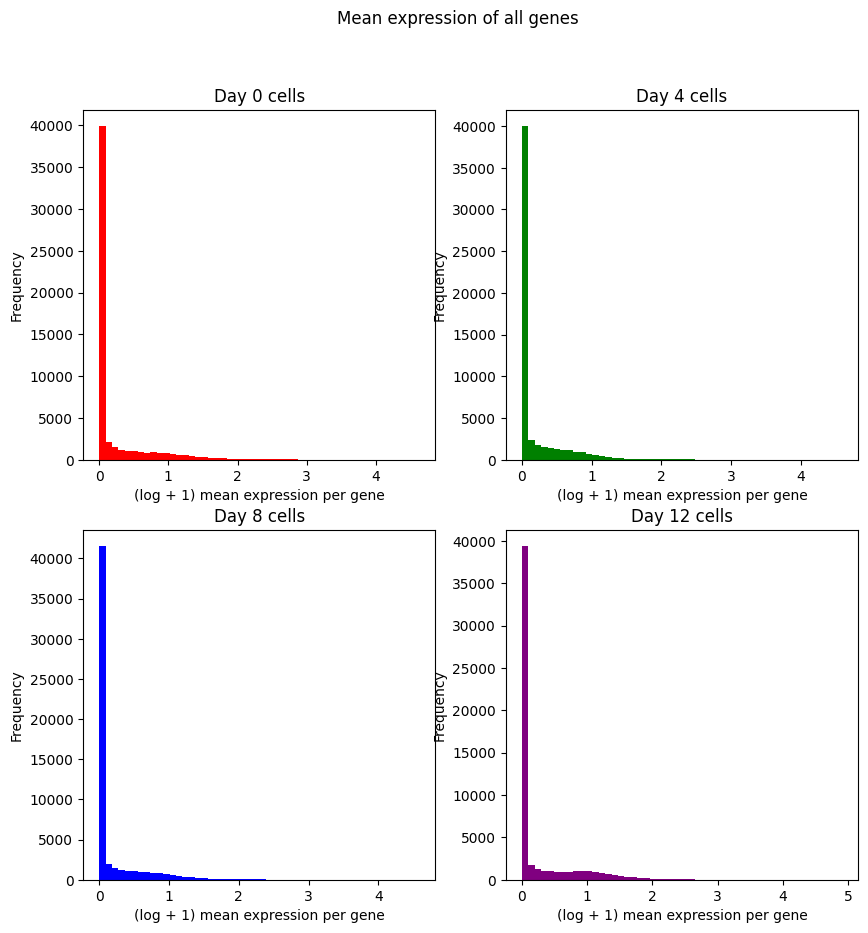

In [41]:
fig, axs = plt.subplots(2, 2, figsize=(10, 10))
plt.suptitle("Mean expression of all genes")
d0_hist = axs[0, 0].hist(np.log10(np.mean(data_d0, axis=1) + 1), bins=50, color="red");
axs[0, 0].set_title("Day 0 cells")
axs[0, 0].set_xlabel("(log + 1) mean expression per gene")
axs[0, 0].set_ylabel("Frequency")
d4_hist = axs[0, 1].hist(np.log10(np.mean(data_d4, axis=1) + 1), bins=50, color="green");
axs[0, 1].set_title("Day 4 cells")
axs[0, 1].set_xlabel("(log + 1) mean expression per gene")
axs[0, 1].set_ylabel("Frequency")
d8_hist = axs[1, 0].hist(np.log10(np.mean(data_d8, axis=1) + 1), bins=50, color="blue");
axs[1, 0].set_title("Day 8 cells")
axs[1, 0].set_xlabel("(log + 1) mean expression per gene")
axs[1, 0].set_ylabel("Frequency")
d12_hist = axs[1, 1].hist(np.log10(np.mean(data_d12, axis=1) + 1), bins=50, color="purple");
axs[1, 1].set_title("Day 12 cells")
axs[1, 1].set_xlabel("(log + 1) mean expression per gene")
axs[1, 1].set_ylabel("Frequency")
plt.show()

In [42]:
# remove cells with mean 0
data_filtered_d0 = data_d0[data_d0.mean(axis=1) > 0]
data_filtered_d4 = data_d4[data_d4.mean(axis=1) > 0]
data_filtered_d8 = data_d8[data_d8.mean(axis=1) > 0]
data_filtered_d12 = data_d12[data_d12.mean(axis=1) > 0]

# display
print(f"{data_d0.shape[0] - data_filtered_d0.shape[0]} genes with zero counts in Day 0 cells")
print(f"{data_d4.shape[0] - data_filtered_d4.shape[0]} genes with zero counts in Day 4 cells")
print(f"{data_d8.shape[0] - data_filtered_d8.shape[0]} genes with zero counts in Day 8 cells")
print(f"{data_d12.shape[0] - data_filtered_d12.shape[0]} genes with zero counts in Day 12 cells")

22628 genes with zero counts in Day 0 cells
19418 genes with zero counts in Day 4 cells
22740 genes with zero counts in Day 8 cells
21871 genes with zero counts in Day 12 cells


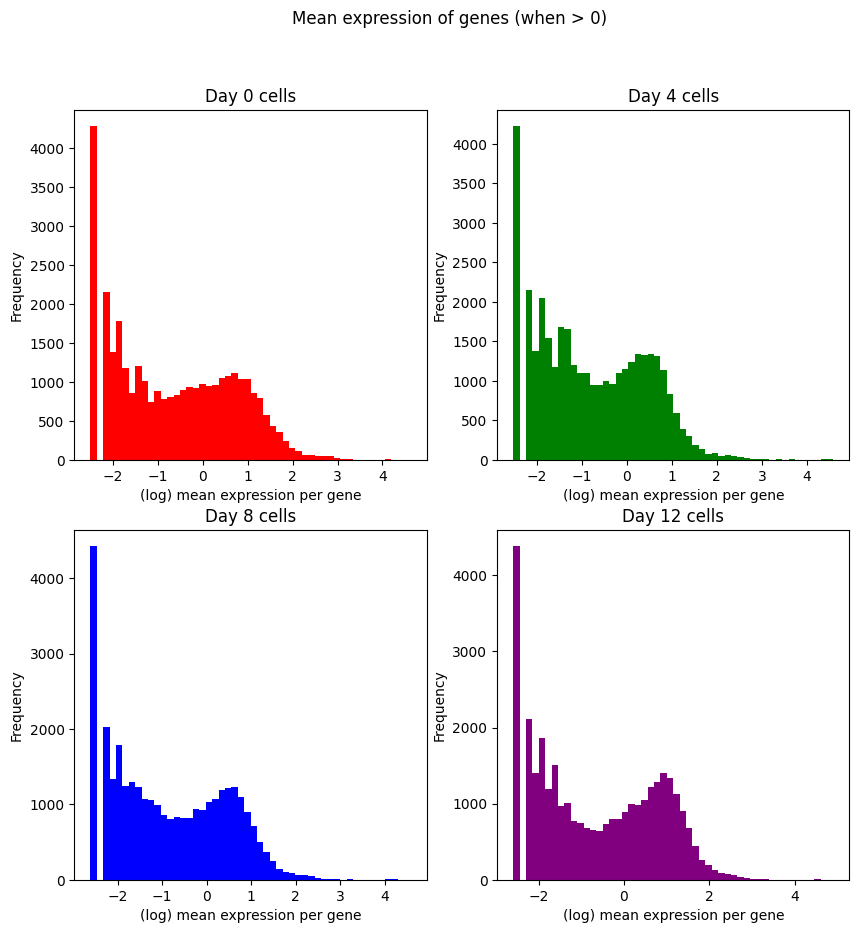

In [43]:
fig, axs = plt.subplots(2, 2, figsize=(10, 10))
plt.suptitle("Mean expression of genes (when > 0)")
d0_hist = axs[0, 0].hist(np.log10(np.mean(data_filtered_d0, axis=1)), bins=50, color="red");
axs[0, 0].set_title("Day 0 cells")
axs[0, 0].set_xlabel("(log) mean expression per gene")
axs[0, 0].set_ylabel("Frequency")
d4_hist = axs[0, 1].hist(np.log10(np.mean(data_filtered_d4, axis=1)), bins=50, color="green");
axs[0, 1].set_title("Day 4 cells")
axs[0, 1].set_xlabel("(log) mean expression per gene")
axs[0, 1].set_ylabel("Frequency")
d8_hist = axs[1, 0].hist(np.log10(np.mean(data_filtered_d8, axis=1)), bins=50, color="blue");
axs[1, 0].set_title("Day 8 cells")
axs[1, 0].set_xlabel("(log) mean expression per gene")
axs[1, 0].set_ylabel("Frequency")
d12_hist = axs[1, 1].hist(np.log10(np.mean(data_filtered_d12, axis=1)), bins=50, color="purple");
axs[1, 1].set_title("Day 12 cells")
axs[1, 1].set_xlabel("(log) mean expression per gene")
axs[1, 1].set_ylabel("Frequency")
plt.show()

In [44]:
# remove cells with mean < 1
thresh = 1
data_thresh_d0 = data_filtered_d0[data_filtered_d0.mean(axis=1) > thresh]
data_thresh_d4 = data_filtered_d4[data_filtered_d4.mean(axis=1) > thresh]
data_thresh_d8 = data_filtered_d8[data_filtered_d8.mean(axis=1) > thresh]
data_thresh_d12 = data_filtered_d12[data_filtered_d12.mean(axis=1) > thresh]

# display
print(f"{data_filtered_d0.shape[0] - data_thresh_d0.shape[0]} genes with mean counts < {thresh} in Day 0 cells")
print(f"{data_filtered_d4.shape[0] - data_thresh_d4.shape[0]} genes with mean counts < {thresh} in Day 4 cells")
print(f"{data_filtered_d8.shape[0] - data_thresh_d8.shape[0]} genes with mean counts < {thresh} in Day 8 cells")
print(f"{data_filtered_d12.shape[0] - data_thresh_d12.shape[0]} genes with mean counts < {thresh} in Day 12 cells")

21199 genes with mean counts < 1 in Day 0 cells
25044 genes with mean counts < 1 in Day 4 cells
22583 genes with mean counts < 1 in Day 8 cells
20517 genes with mean counts < 1 in Day 12 cells


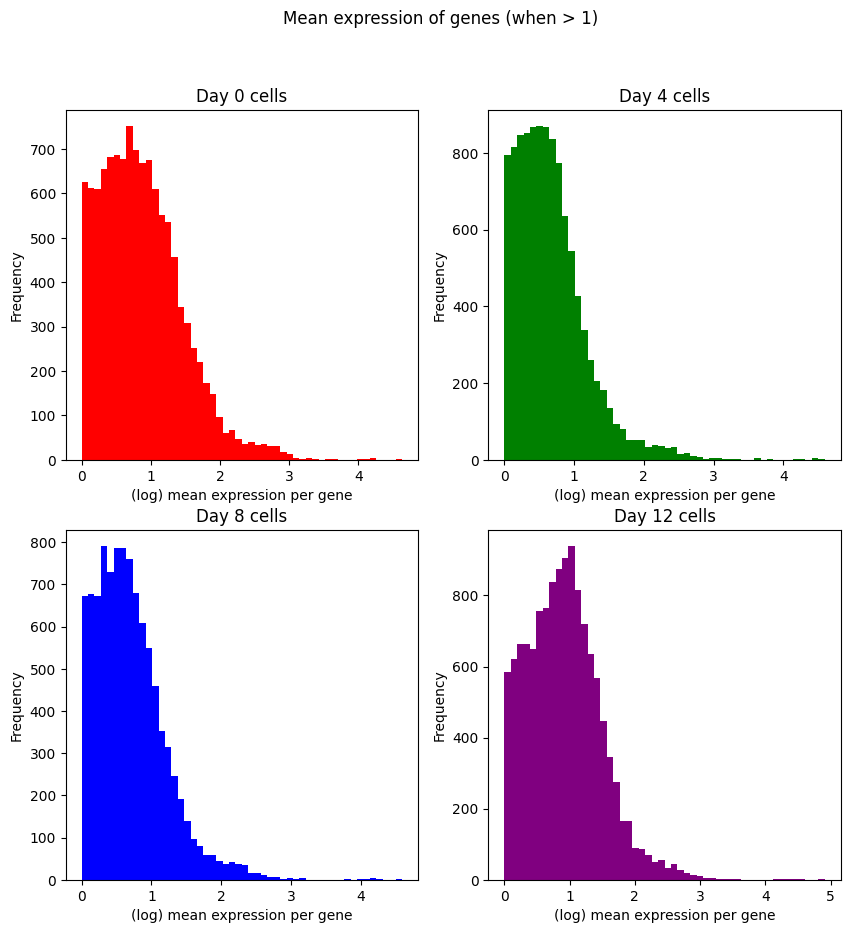

In [45]:
fig, axs = plt.subplots(2, 2, figsize=(10, 10))
plt.suptitle("Mean expression of genes (when > 1)")
d0_hist = axs[0, 0].hist(np.log10(np.mean(data_thresh_d0, axis=1)), bins=50, color="red");
axs[0, 0].set_title("Day 0 cells")
axs[0, 0].set_xlabel("(log) mean expression per gene")
axs[0, 0].set_ylabel("Frequency")
d4_hist = axs[0, 1].hist(np.log10(np.mean(data_thresh_d4, axis=1)), bins=50, color="green");
axs[0, 1].set_title("Day 4 cells")
axs[0, 1].set_xlabel("(log) mean expression per gene")
axs[0, 1].set_ylabel("Frequency")
d8_hist = axs[1, 0].hist(np.log10(np.mean(data_thresh_d8, axis=1)), bins=50, color="blue");
axs[1, 0].set_title("Day 8 cells")
axs[1, 0].set_xlabel("(log) mean expression per gene")
axs[1, 0].set_ylabel("Frequency")
d12_hist = axs[1, 1].hist(np.log10(np.mean(data_thresh_d12, axis=1)), bins=50, color="purple");
axs[1, 1].set_title("Day 12 cells")
axs[1, 1].set_xlabel("(log) mean expression per gene")
axs[1, 1].set_ylabel("Frequency")
plt.show()

### Check mean cell counts after gene filtering

In [51]:
# mean cell counts
d0_thresh_cell_means = data_thresh_d0.mean(axis=0)
d4_thresh_cell_means = data_thresh_d4.mean(axis=0)
d8_thresh_cell_means = data_thresh_d8.mean(axis=0)
d12_thresh_cell_means = data_thresh_d12.mean(axis=0)

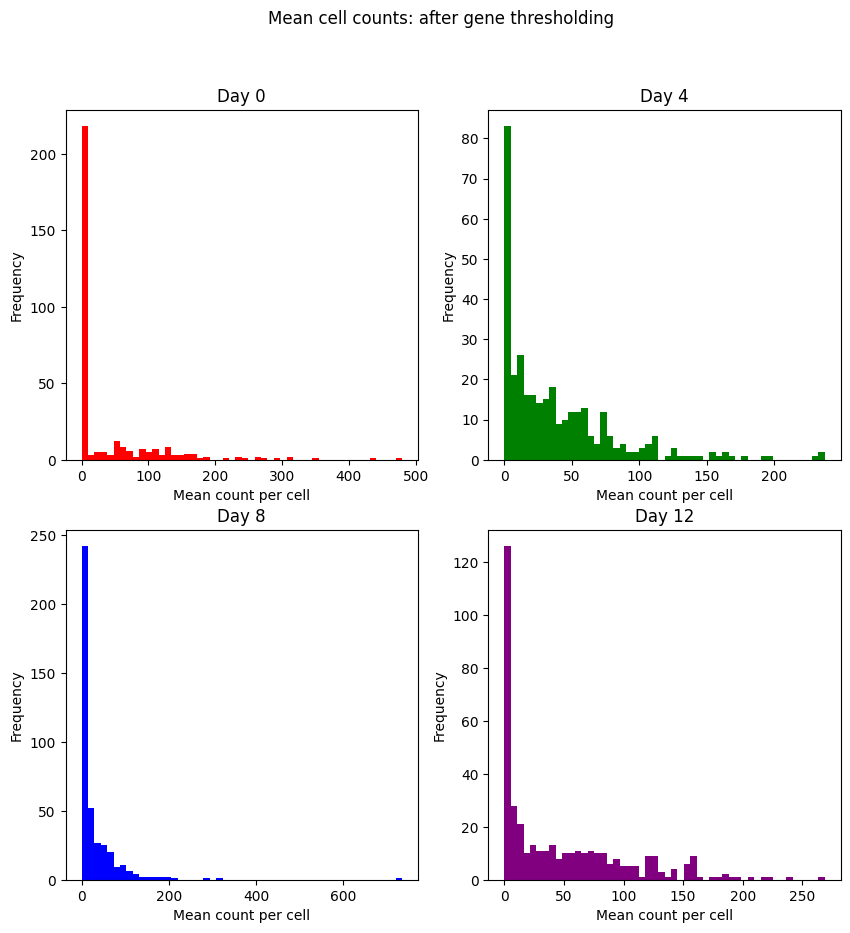

In [52]:
fig, axs = plt.subplots(2, 2, figsize=(10, 10))
plt.suptitle("Mean cell counts: after gene thresholding")
d0_hist = axs[0, 0].hist(d0_thresh_cell_means, bins=50, color="red");
axs[0, 0].set_title("Day 0")
axs[0, 0].set_xlabel("Mean count per cell")
axs[0, 0].set_ylabel("Frequency")
d4_hist = axs[0, 1].hist(d4_thresh_cell_means, bins=50, color="green");
axs[0, 1].set_title("Day 4")
axs[0, 1].set_xlabel("Mean count per cell")
axs[0, 1].set_ylabel("Frequency")
d8_hist = axs[1, 0].hist(d8_thresh_cell_means, bins=50, color="blue");
axs[1, 0].set_title("Day 8")
axs[1, 0].set_xlabel("Mean count per cell")
axs[1, 0].set_ylabel("Frequency")
d12_hist = axs[1, 1].hist(d12_thresh_cell_means, bins=50, color="purple");
axs[1, 1].set_title("Day 12")
axs[1, 1].set_xlabel("Mean count per cell")
axs[1, 1].set_ylabel("Frequency")
plt.show()

Still see outlying cell in day 8

### Save data

In [53]:
#data_thresh_d0.to_csv("./GSE151334_d0_counts_thresh.csv")
#data_thresh_d4.to_csv("./GSE151334_d4_counts_thresh.csv")
#data_thresh_d8.to_csv("./GSE151334_d8_counts_thresh.csv")
#data_thresh_d12.to_csv("./GSE151334_d12_counts_thresh.csv")

### Reduce to genes in common

Filtering genes for each day separately means genes may only be present in some days and not others.

To ensure we always have results for genes across all days can reduce the datasets to only the genes which are common to all filtered day datasets.

In [54]:
# select genes for each day
d0_genes = data_thresh_d0.index
d4_genes = data_thresh_d4.index
d8_genes = data_thresh_d8.index
d12_genes = data_thresh_d12.index

# find common genes
d_common_genes = set(d0_genes) & set(d4_genes) & set(d8_genes) & set(d12_genes)
d_common_genes = list(d_common_genes)

# reduce
data_common_d0 = data_thresh_d0.loc[d_common_genes]
data_common_d4 = data_thresh_d4.loc[d_common_genes]
data_common_d8 = data_thresh_d8.loc[d_common_genes]
data_common_d12 = data_thresh_d12.loc[d_common_genes]

# display reduction
print(f"{len(d0_genes)} genes for day 0")
print(f"{len(d4_genes)} genes for day 4")
print(f"{len(d8_genes)} genes for day 8")
print(f"{len(d12_genes)} genes for day 12")
print(f"{len(d_common_genes)} genes in common for all days")

11466 genes for day 0
10831 genes for day 4
9970 genes for day 8
12905 genes for day 12
7558 genes in common for all days


### Check final distributions of counts per cell & gene

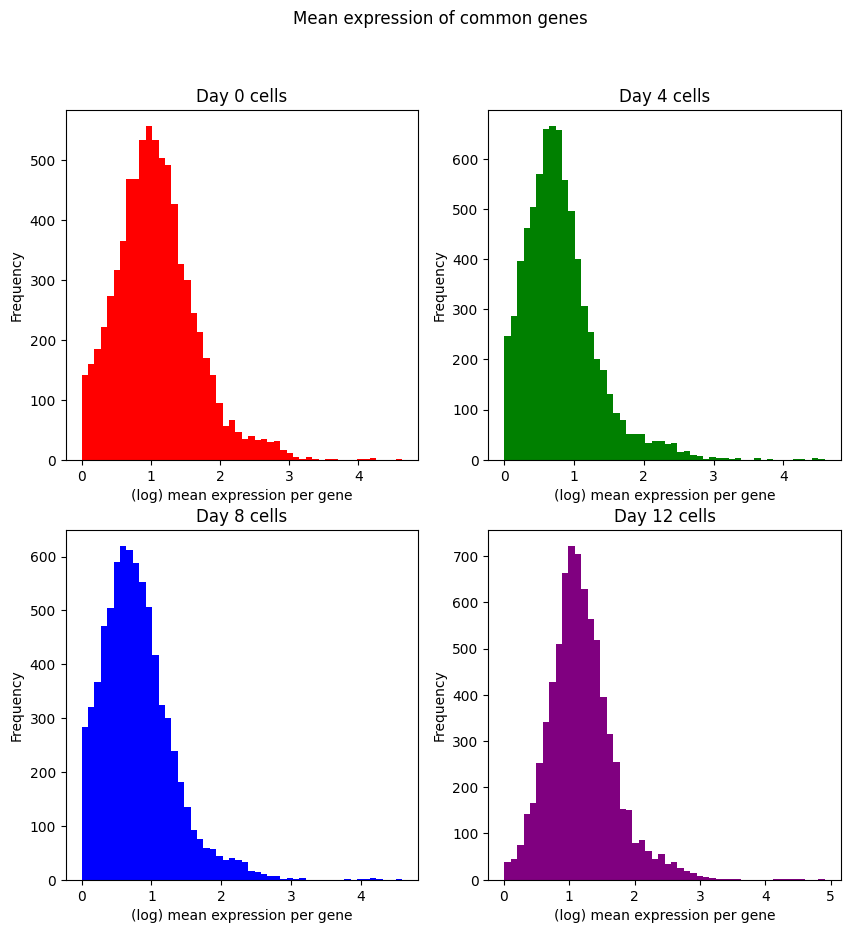

In [55]:
fig, axs = plt.subplots(2, 2, figsize=(10, 10))
plt.suptitle("Mean expression of common genes")
d0_hist = axs[0, 0].hist(np.log10(np.mean(data_common_d0, axis=1)), bins=50, color="red");
axs[0, 0].set_title("Day 0 cells")
axs[0, 0].set_xlabel("(log) mean expression per gene")
axs[0, 0].set_ylabel("Frequency")
d4_hist = axs[0, 1].hist(np.log10(np.mean(data_common_d4, axis=1)), bins=50, color="green");
axs[0, 1].set_title("Day 4 cells")
axs[0, 1].set_xlabel("(log) mean expression per gene")
axs[0, 1].set_ylabel("Frequency")
d8_hist = axs[1, 0].hist(np.log10(np.mean(data_common_d8, axis=1)), bins=50, color="blue");
axs[1, 0].set_title("Day 8 cells")
axs[1, 0].set_xlabel("(log) mean expression per gene")
axs[1, 0].set_ylabel("Frequency")
d12_hist = axs[1, 1].hist(np.log10(np.mean(data_common_d12, axis=1)), bins=50, color="purple");
axs[1, 1].set_title("Day 12 cells")
axs[1, 1].set_xlabel("(log) mean expression per gene")
axs[1, 1].set_ylabel("Frequency")
plt.show()

In [56]:
# mean cell counts
d0_common_cell_means = data_common_d0.mean(axis=0)
d4_common_cell_means = data_common_d4.mean(axis=0)
d8_common_cell_means = data_common_d8.mean(axis=0)
d12_common_cell_means = data_common_d12.mean(axis=0)

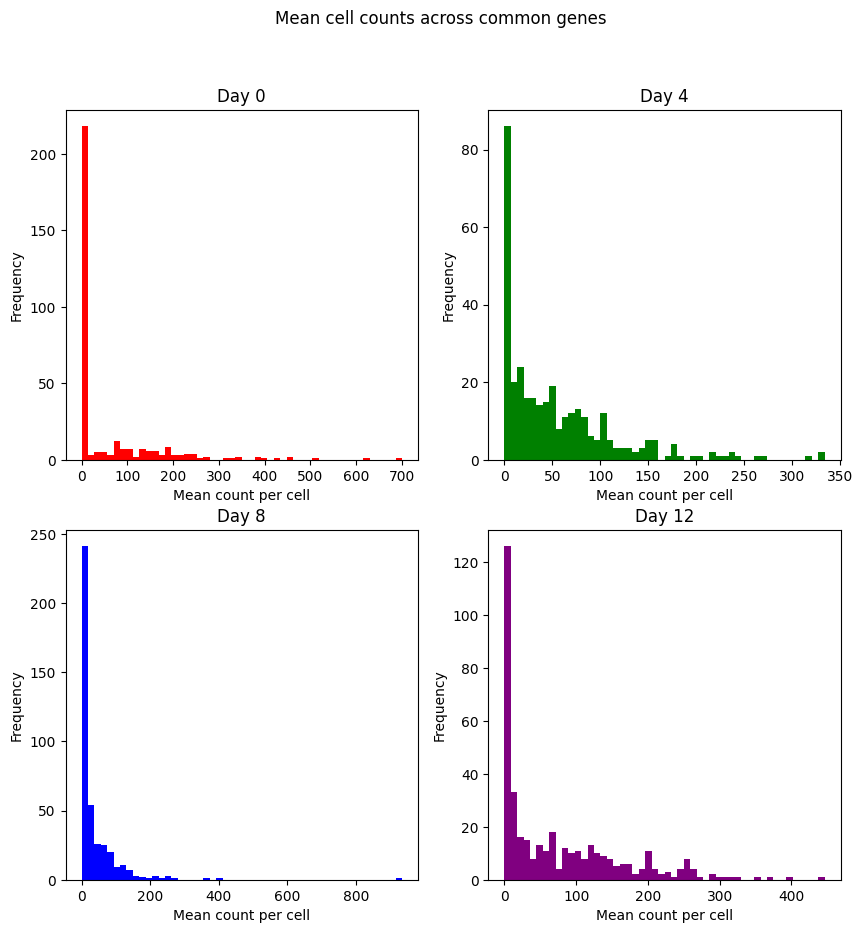

In [57]:
fig, axs = plt.subplots(2, 2, figsize=(10, 10))
plt.suptitle("Mean cell counts across common genes")
d0_hist = axs[0, 0].hist(d0_common_cell_means, bins=50, color="red");
axs[0, 0].set_title("Day 0")
axs[0, 0].set_xlabel("Mean count per cell")
axs[0, 0].set_ylabel("Frequency")
d4_hist = axs[0, 1].hist(d4_common_cell_means, bins=50, color="green");
axs[0, 1].set_title("Day 4")
axs[0, 1].set_xlabel("Mean count per cell")
axs[0, 1].set_ylabel("Frequency")
d8_hist = axs[1, 0].hist(d8_common_cell_means, bins=50, color="blue");
axs[1, 0].set_title("Day 8")
axs[1, 0].set_xlabel("Mean count per cell")
axs[1, 0].set_ylabel("Frequency")
d12_hist = axs[1, 1].hist(d12_common_cell_means, bins=50, color="purple");
axs[1, 1].set_title("Day 12")
axs[1, 1].set_xlabel("Mean count per cell")
axs[1, 1].set_ylabel("Frequency")
plt.show()

In [59]:
d8_common_cell_means.sort_values(ascending=False)

mESC_EB_d8_J24_S240.1    934.779307
mESC_EB_d8_D16_S88       399.373776
mESC_EB_d8_N24_S336      366.357237
mESC_EB_d8_P18_S378      265.595263
mESC_EB_d8_P14_S374      256.603996
                            ...    
mESC_EB_d8_E2_S98          0.074358
mESC_EB_d8_O4_S340         0.067743
mESC_EB_d8_E14_S110        0.043001
mESC_EB_d8_C7_S55.1        0.039296
mESC_EB_d8_C1_S49          0.007012
Length: 410, dtype: float64

### Save data

In [60]:
data_common_d0.to_csv("./GSE151334_d0_counts_common.csv")
data_common_d4.to_csv("./GSE151334_d4_counts_common.csv")
data_common_d8.to_csv("./GSE151334_d8_counts_common.csv")
data_common_d12.to_csv("./GSE151334_d12_counts_common.csv")

# Note

Probably should not do below, as filtering then separating cells by day means that genes in some day datasets can have means < 1 and even = 0

Should instead use above, where cells are first separated by day then filtered individually. If needed can then take only the genes which are present in all day datasets to ensure always have results for genes across all days.

# Keep cells togther for filtering

Choose to ignore the additional `p2` and `p3` cells for day 0

In [121]:
columns_d = [name for name in data.columns if 'mESC_EB_d' in name]
data_d = data[columns_d]

### Outlying cells

In [122]:
# mean cell counts
cell_means = data_d.mean(axis=0)

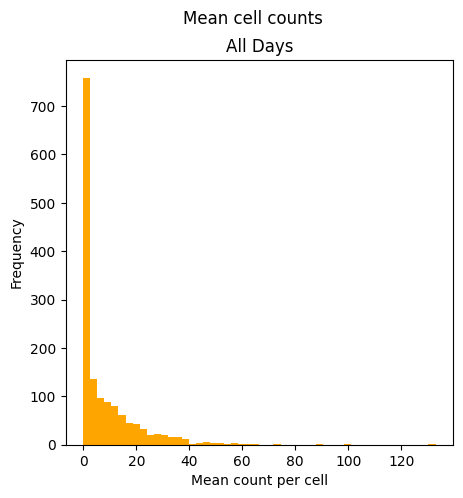

In [127]:
fig, axs = plt.subplots(1, 1, figsize=(5, 5), squeeze=False)
plt.suptitle("Mean cell counts")
d_hist = axs[0, 0].hist(cell_means, bins=50, color="orange");
axs[0, 0].set_title("All Days")
axs[0, 0].set_xlabel("Mean count per cell")
axs[0, 0].set_ylabel("Frequency")
plt.show()

Few potential outlying cells

### Filter low expression genes

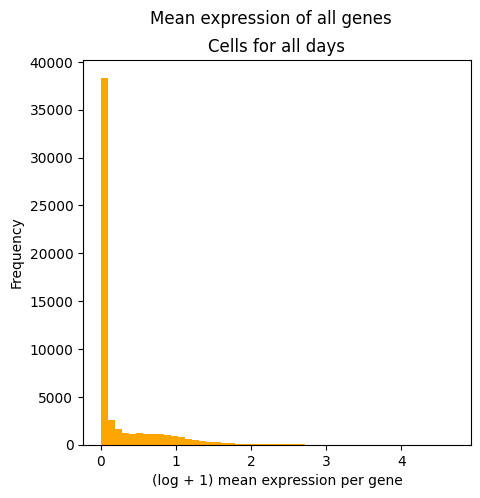

In [129]:
fig, axs = plt.subplots(1, 1, figsize=(5, 5), squeeze=False)
plt.suptitle("Mean expression of all genes")
d_hist = axs[0, 0].hist(np.log10(np.mean(data_d, axis=1) + 1), bins=50, color="orange");
axs[0, 0].set_title("Cells for all days")
axs[0, 0].set_xlabel("(log + 1) mean expression per gene")
axs[0, 0].set_ylabel("Frequency")
plt.show()

In [130]:
# remove cells with mean 0
data_filtered_d = data_d[data_d.mean(axis=1) > 0]

# display
print(f"{data_d.shape[0] - data_filtered_d.shape[0]} genes with zero counts in cells for all days")

12036 genes with zero counts in cells for all days


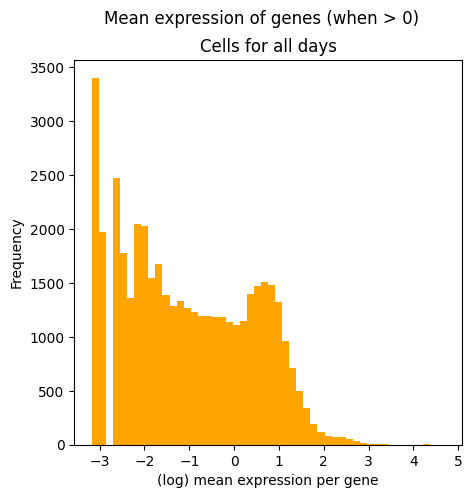

In [132]:
fig, axs = plt.subplots(1, 1, figsize=(5, 5), squeeze=False)
plt.suptitle("Mean expression of genes (when > 0)")
d_hist = axs[0, 0].hist(np.log10(np.mean(data_filtered_d, axis=1)), bins=50, color="orange");
axs[0, 0].set_title("Cells for all days")
axs[0, 0].set_xlabel("(log) mean expression per gene")
axs[0, 0].set_ylabel("Frequency")
plt.show()

In [133]:
# remove cells with mean < 1
thresh = 1
data_thresh_d = data_filtered_d[data_filtered_d.mean(axis=1) > thresh]

# display
print(f"{data_filtered_d.shape[0] - data_thresh_d.shape[0]} genes with mean counts < {thresh} in cells for all days")

30855 genes with mean counts < 1 in cells for all days


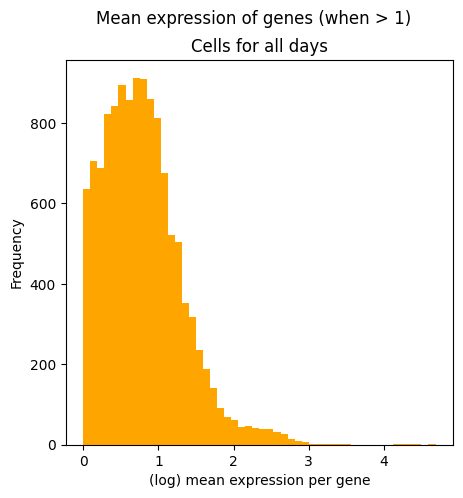

In [135]:
fig, axs = plt.subplots(1, 1, figsize=(5, 5), squeeze=False)
plt.suptitle("Mean expression of genes (when > 1)")
d_hist = axs[0, 0].hist(np.log10(np.mean(data_thresh_d, axis=1)), bins=50, color="orange");
axs[0, 0].set_title("Cells for all days")
axs[0, 0].set_xlabel("(log) mean expression per gene")
axs[0, 0].set_ylabel("Frequency")
plt.show()

### Check mean cell counts after gene filtering

In [136]:
# mean cell counts
d_thresh_cell_means = data_thresh_d.mean(axis=0)

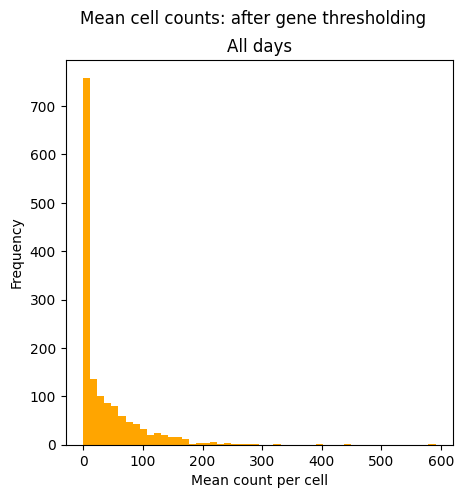

In [138]:
fig, axs = plt.subplots(1, 1, figsize=(5, 5), squeeze=False)
plt.suptitle("Mean cell counts: after gene thresholding")
d0_hist = axs[0, 0].hist(d_thresh_cell_means, bins=50, color="orange");
axs[0, 0].set_title("All days")
axs[0, 0].set_xlabel("Mean count per cell")
axs[0, 0].set_ylabel("Frequency")
plt.show()

Still see some outlying cells

### Separate cells by day

In [139]:
d0_columns_d = [name for name in data_thresh_d.columns if 'mESC_EB_d0' in name]
d4_columns_d = [name for name in data_thresh_d.columns if 'mESC_EB_d4' in name]
d8_columns_d = [name for name in data_thresh_d.columns if 'mESC_EB_d8' in name]
d12_columns_d = [name for name in data_thresh_d.columns if 'mESC_EB_d12' in name]

data_thresh_keep_d0 = data_thresh_d[d0_columns_d]
data_thresh_keep_d4 = data_thresh_d[d4_columns_d]
data_thresh_keep_d8 = data_thresh_d[d8_columns_d]
data_thresh_keep_d12 = data_thresh_d[d12_columns_d]

c:\Users\willi\Documents\ProjectPaper\M5R_venv\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


ValueError: supplied range of [-inf, 4.618965908648942] is not finite

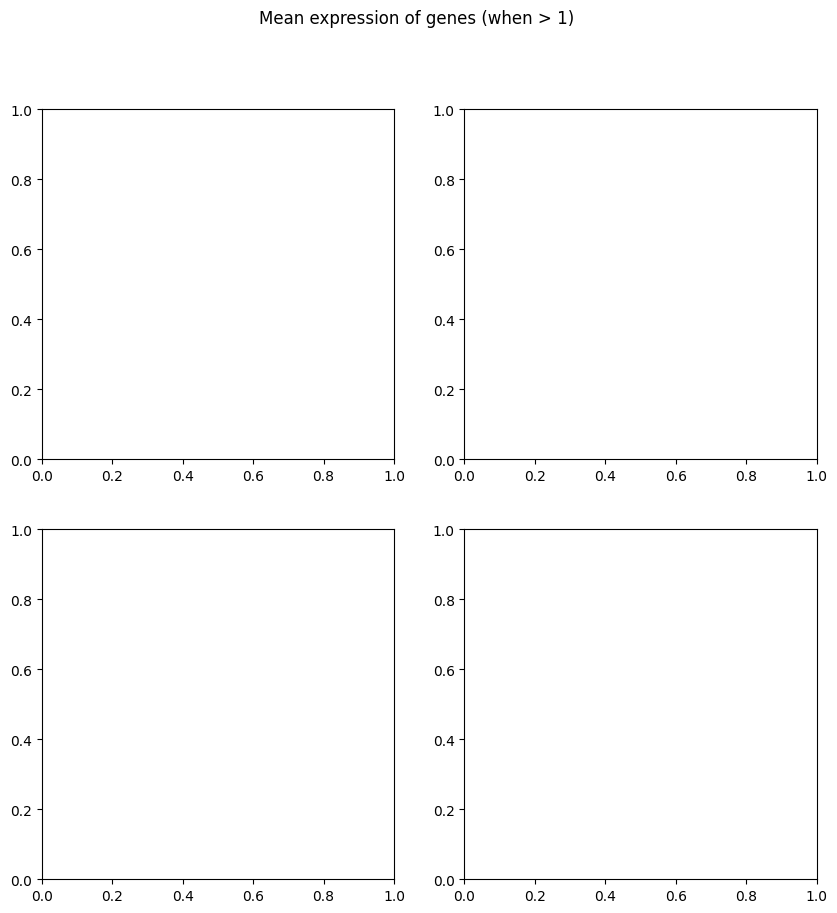

In [140]:
fig, axs = plt.subplots(2, 2, figsize=(10, 10))
plt.suptitle("Mean expression of genes (when > 1)")
d0_hist = axs[0, 0].hist(np.log10(np.mean(data_thresh_keep_d0, axis=1)), bins=50, color="red");
axs[0, 0].set_title("Day 0 cells")
axs[0, 0].set_xlabel("(log) mean expression per gene")
axs[0, 0].set_ylabel("Frequency")
d4_hist = axs[0, 1].hist(np.log10(np.mean(data_thresh_keep_d4, axis=1)), bins=50, color="green");
axs[0, 1].set_title("Day 4 cells")
axs[0, 1].set_xlabel("(log) mean expression per gene")
axs[0, 1].set_ylabel("Frequency")
d8_hist = axs[1, 0].hist(np.log10(np.mean(data_thresh_keep_d8, axis=1)), bins=50, color="blue");
axs[1, 0].set_title("Day 8 cells")
axs[1, 0].set_xlabel("(log) mean expression per gene")
axs[1, 0].set_ylabel("Frequency")
d12_hist = axs[1, 1].hist(np.log10(np.mean(data_thresh_keep_d12, axis=1)), bins=50, color="purple");
axs[1, 1].set_title("Day 12 cells")
axs[1, 1].set_xlabel("(log) mean expression per gene")
axs[1, 1].set_ylabel("Frequency")
plt.show()

### Save data

In [ ]:
#data_thresh_sep_d0.to_csv("./GSE151334_d0_counts_thresh.csv")
#data_thresh_sep_d4.to_csv("./GSE151334_d4_counts_thresh.csv")
#data_thresh_sep_d8.to_csv("./GSE151334_d8_counts_thresh.csv")
#data_thresh_sep_d12.to_csv("./GSE151334_d12_counts_thresh.csv")